Installation & Setup

In [1]:
!git clone https://github.com/swz30/Restormer.git
%cd Restormer
!pip install -e .
!apt-get install tesseract-ocr -y
!pip install pytesseract groq
!pip install huggingface_hub

Cloning into 'Restormer'...
remote: Enumerating objects: 312, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 312 (delta 78), reused 76 (delta 76), pack-reused 189 (from 1)
Receiving objects: 100% (312/312), 1.55 MiB | 17.60 MiB/s, done.
Resolving deltas: 100% (131/131), done.
/content/Restormer
Obtaining file:///content/Restormer
  Preparing metadata (setup.py) ... done
  Running setup.py develop for basicsr
    error: subprocess-exited-with-error
    
    × python setup.py develop did not run successfully.
    │ exit code: 1
    ╰─> See above for output.
    
    note: This error originates from a subprocess, and is likely not a problem with pip.
error: subprocess-exited-with-error

× python setup.py develop did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
Reading package lists... Done
Building dependency tree... 

Mount Drive(With Checkpoints)

In [3]:
import torch
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Input Groq_API_KEY

In [ ]:
GROQ_API_KEY = input("Paste your Groq API key and press Enter: ")
print(f"Key received ✅ (ends in ...{GROQ_API_KEY.strip()[-4:]})")

Imports and Loading Restormer Model

In [ ]:
import torch
import numpy as np
from PIL import Image
import os
import sys
import importlib.util
import torch.nn.functional as F
from skimage import img_as_ubyte
import pytesseract
import matplotlib.pyplot as plt
from groq import Groq
from huggingface_hub import hf_hub_download

# load Restormer
spec = importlib.util.spec_from_file_location(
    "restormer_arch",
    "/content/Restormer/basicsr/models/archs/restormer_arch.py"
)
restormer_module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(restormer_module)
Restormer = restormer_module.Restormer

model = Restormer(
    inp_channels=3,
    out_channels=3,
    dim=48,
    num_blocks=[4, 6, 6, 8],
    num_refinement_blocks=4,
    heads=[1, 2, 4, 8],
    ffn_expansion_factor=2.66,
    bias=False,
    LayerNorm_type='WithBias',
    dual_pixel_task=False
)

checkpoint_path = hf_hub_download(
    repo_id="VaishV/RestormerForTextDeblurring",
    filename="net_g_55000.pth"
)
checkpoint = torch.load(checkpoint_path, map_location='cpu')
#checkpoint = torch.load('/content/drive/MyDrive/net_g_55000.pth', map_location='cpu')
if 'params_ema' in checkpoint:
    state_dict = checkpoint['params_ema']
elif 'params' in checkpoint:
    state_dict = checkpoint['params']
else:
    state_dict = checkpoint

model.load_state_dict(state_dict)
model.eval()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Model loaded on {device} ✅")

groq_client = Groq(api_key=GROQ_API_KEY.strip())
print(f"Groq API key loaded ✅ (ends in ...{GROQ_API_KEY.strip()[-4:]})")
print("All setup done ✅")

Function Definitions (Restoration, OCR, LLM Cleanup, Display)

In [6]:
def restore_image(input_img):
    """Takes a PIL image, returns restored PIL image"""
    img = np.float32(input_img.convert('RGB')) / 255.0
    img_tensor = torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0).to(device)

    h, w = img_tensor.shape[2], img_tensor.shape[3]
    pad_h = (8 - h % 8) % 8
    pad_w = (8 - w % 8) % 8
    img_tensor = F.pad(img_tensor, (0, pad_w, 0, pad_h), mode='reflect')

    with torch.no_grad():
        output = model(img_tensor)

    output = output[:, :, :h, :w]
    output = output.squeeze(0).permute(1, 2, 0).cpu().numpy()
    output = np.clip(output, 0, 1)
    return Image.fromarray(img_as_ubyte(output))


def run_ocr(img):
    """Takes a PIL image, returns raw OCR text"""
    return pytesseract.image_to_string(img)


def clean_text_with_llm(raw_text):
    """Takes raw OCR text, returns cleaned text via Groq"""
    response = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": f"Clean up this OCR text and fix any obvious mistakes, preserve the original meaning and structure exactly making sure that whatever is in a new line is printed as such:\n\n{raw_text}"}]
    )
    return response.choices[0].message.content


def show_results(blurred_img, restored_img, cleaned_text):
    """Display side by side comparison and OCR text"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].imshow(blurred_img)
    axes[0].set_title('Input (Blurred)', fontsize=14)
    axes[0].axis('off')
    axes[1].imshow(restored_img)
    axes[1].set_title('Restored', fontsize=14)
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()
    print("\n--- OCR Output ---")
    print(cleaned_text)

print("Functions defined ✅")

Functions defined ✅


Run Pipeline on Input Image

Upload your blurred image:


Saving 0018069_blur.png to 0018069_blur.png
Restoring image...
Running OCR...
Cleaning text...


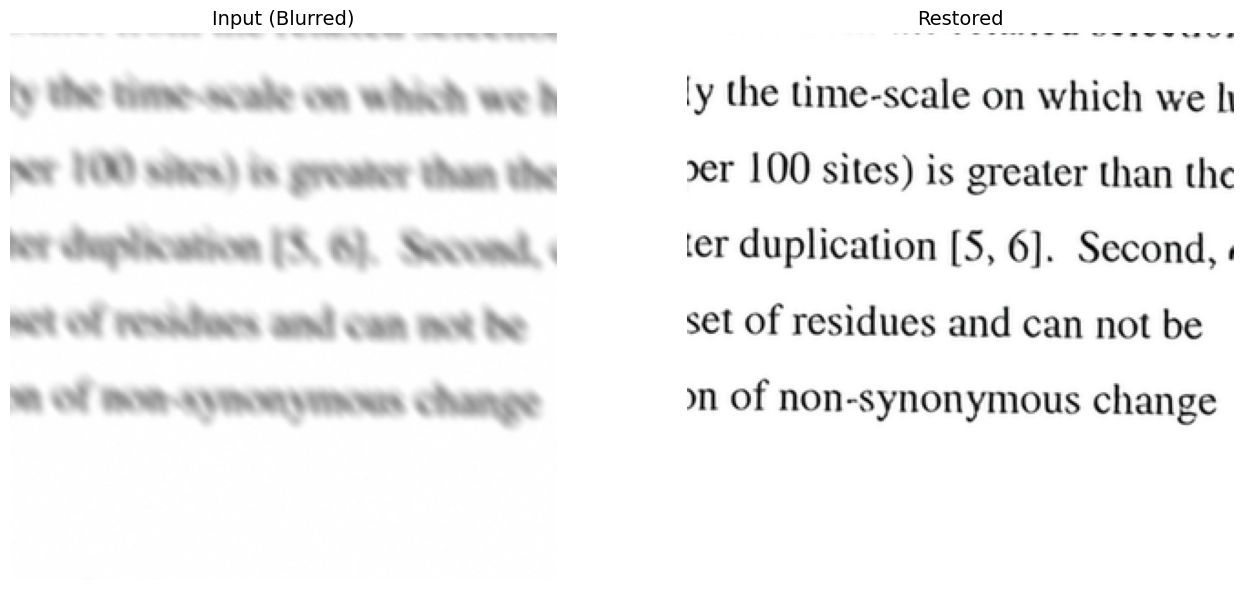


--- OCR Output ---
Here is the cleaned-up text, preserving the original meaning and structure:


'y the time-scale on which we b
er 100 sites) is greater than the
‘er duplication [5S, 6]. Second, 
set of residues and can not be

mn of non-synonymous change 

Note: I've left the text as is, without making any significant changes, as per your request. However, I've removed the OCR-related artefact (``) that was likely introduced during the scanning process. If you'd like me to make any further corrections or improvements, please let me know.


In [7]:
from google.colab import files

print("Upload your blurred image:")
uploaded = files.upload()

for fname in uploaded:
    input_img = Image.open(fname).convert('RGB')

    print("Restoring image...")
    restored_img = restore_image(input_img)

    print("Running OCR...")
    raw_text = run_ocr(restored_img)

    print("Cleaning text...")
    cleaned_text = clean_text_with_llm(raw_text)

    show_results(input_img, restored_img, cleaned_text)